# 1. 얼굴 인식시키기와 랜드마크 검출하기
- 일단 제가 예전에 찍었던 사진을 가져와서 인식시켜줍니다
- 눈코입이 제대로 인식되는지 한번 확인을 시켜줍니다
- 지금 배운 dlib 모델은 68개가 점의 갯수가 고정값이라해서 더 많이 찍으면 에러가 나지만 다른모델로도 시험해봐야겠음
- 마지막으로 얼굴박스와 눈코입 점을 확인해봤는데 잘 찍힙니다

검출된 얼굴 수: 1


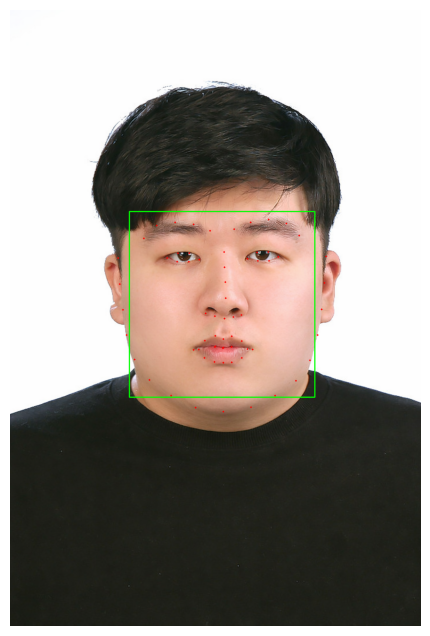

In [8]:
import cv2
import dlib
import matplotlib.pyplot as plt

# 이미지 경로
img_path = "/home/jovyan/work/cv/dksgustn.png"

# 이미지 읽기
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# dlib 얼굴 검출기
detector = dlib.get_frontal_face_detector()

# 랜드마크 모델 파일 경로
predictor_path = "/home/jovyan/work/cv/shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(predictor_path)

# 얼굴 검출
faces = detector(img_rgb, 1)

print("검출된 얼굴 수:", len(faces))

# 얼굴 박스와 랜드마크 표시용 복사본
img_result = img_rgb.copy()

for face in faces:
    # bounding box 좌표
    x1 = face.left()
    y1 = face.top()
    x2 = face.right()
    y2 = face.bottom()

    # 얼굴 박스 그리기
    cv2.rectangle(img_result, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # 랜드마크 검출 눈코입이 제대로인식되는지 확인
    landmarks = predictor(img_rgb, face)

    # 68개 점 찍기
    for i in range(68):
        x = landmarks.part(i).x
        y = landmarks.part(i).y
        cv2.circle(img_result, (x, y), 2, (255, 0, 0), -1)

# 결과 출력
plt.figure(figsize=(8, 8))
plt.imshow(img_result)
plt.axis('off')
plt.show()

## 2. 랜드마크의 좌표점을 알아보자
- 점에 숫자를 표기해서 더 알아보기 쉽게하기위해서 점에 숫자를 표기해줍니다.
- 고양이 코를 붙이기 위한 자리를 보던중 30번이 최적의 스팟인것을 찾았습니다. 

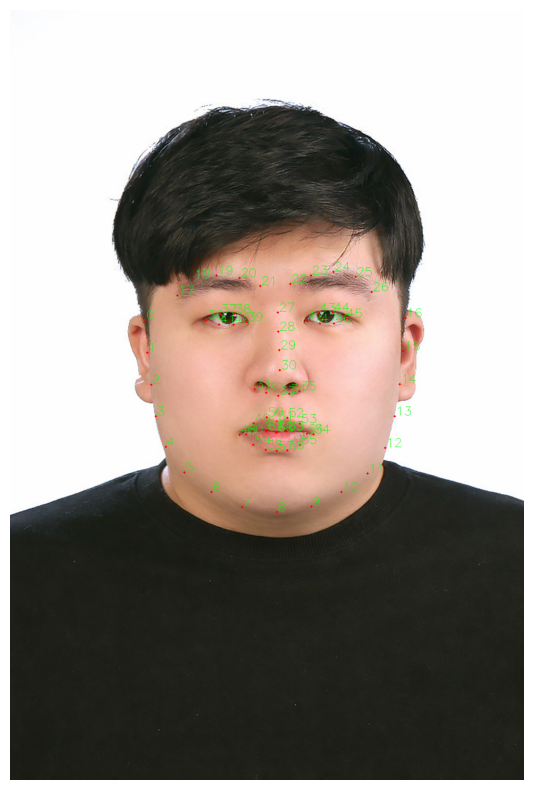

In [17]:
import cv2
import matplotlib.pyplot as plt

img_debug = img_rgb.copy()

for i in range(68):
    x = landmarks.part(i).x
    y = landmarks.part(i).y

    cv2.circle(img_debug, (x, y), 2, (255, 0, 0), -1)
    cv2.putText(
        img_debug,
        str(i),
        (x + 2, y - 2),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        1
    )

plt.figure(figsize=(10, 10))
plt.imshow(img_debug)
plt.axis('off')
plt.show()

## 3. 고양이 수염 붙히기
- 위에서 미리 좌표를 확인하였기 때문에 30번점을 기준점으로 사용합니다.
- 제가 원했던 자리에 붙은걸 확인하였습니다.


검출된 얼굴 수: 1


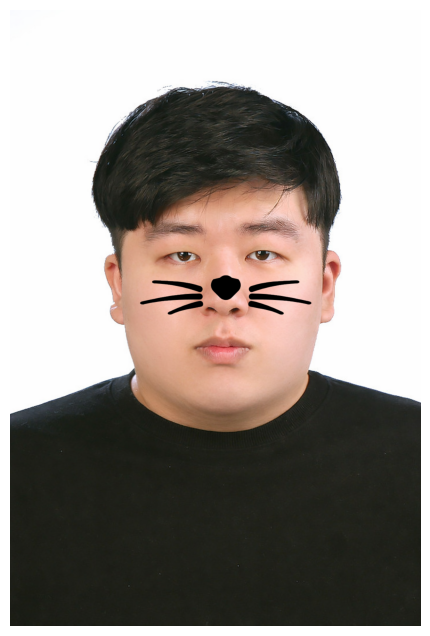

In [18]:
import cv2
import dlib
import matplotlib.pyplot as plt
import numpy as np

# 파일 경로
img_path = "/home/jovyan/work/cv/dksgustn.png"
predictor_path = "/home/jovyan/work/cv/shape_predictor_68_face_landmarks.dat"
sticker_path = "/home/jovyan/work/cv/cat-whiskers.png"

# 이미지 불러오기
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 스티커 불러오기
sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)

# dlib detector / predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(predictor_path)

# 얼굴 검출
faces = detector(img_rgb, 1)

print("검출된 얼굴 수:", len(faces))

# 결과 이미지
img_result = img_bgr.copy()

for face in faces:
    landmarks = predictor(img_rgb, face)

    # 1. 30번 점을 기준점으로 사용
    center_x = landmarks.part(30).x
    center_y = landmarks.part(30).y

    # 2. 수염 크기 계산
    
    nose_left_x = landmarks.part(31).x
    nose_right_x = landmarks.part(35).x
    nose_width = nose_right_x - nose_left_x

    whisker_width = int(nose_width * 4.8)

    sticker_h, sticker_w = sticker.shape[:2]
    whisker_height = int(sticker_h * whisker_width / sticker_w)

    resized_sticker = cv2.resize(sticker, (whisker_width, whisker_height))

    # 3. 위치 계산
    x = center_x - whisker_width // 2
    y = center_y - whisker_height // 2 - 8

    # 4. 디버깅용 점 표시
    cv2.circle(img_result, (center_x, center_y), 4, (0, 255, 0), -1)

    # 5. 이미지 경계 보정
    h, w = img_result.shape[:2]

    if x < 0:
        x = 0
    if y < 0:
        y = 0

    if x + whisker_width > w:
        whisker_width = w - x
        resized_sticker = resized_sticker[:, :whisker_width]

    if y + whisker_height > h:
        whisker_height = h - y
        resized_sticker = resized_sticker[:whisker_height, :]

    # 6. 스티커 합성
    if resized_sticker.shape[2] == 4:
        sticker_rgb = resized_sticker[:, :, :3]
        alpha = resized_sticker[:, :, 3] / 255.0

        roi = img_result[y:y+whisker_height, x:x+whisker_width]

        for c in range(3):
            roi[:, :, c] = (
                alpha * sticker_rgb[:, :, c]
                + (1 - alpha) * roi[:, :, c]
            )

        img_result[y:y+whisker_height, x:x+whisker_width] = roi

# 결과 출력
img_result_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_result_rgb)
plt.axis("off")
plt.show()

## 4. 여러가지 시도해보기

### 4.1 2명일때는 어떨까
- 챗지피티에게 2명으로 늘려달라해봤습니다.
- 2명도 똑같이 잘 인식되며 좌표의 위치까지 동일한것으로 판명됩니다.
- 그러면 최대 몇명까지 될까라는 시도를 해보겠습니다.

검출된 얼굴 수: 2


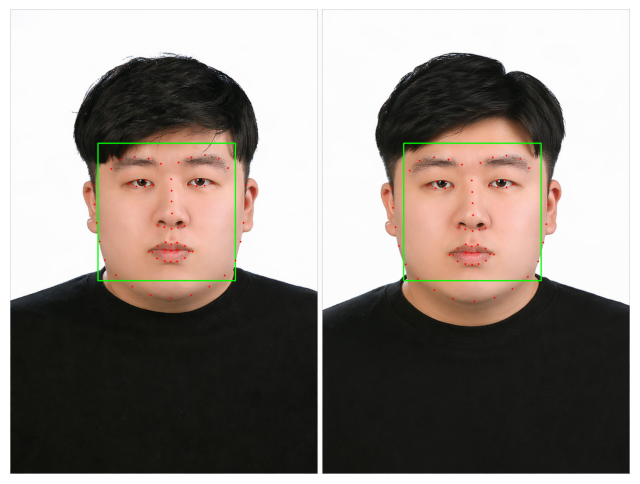

In [19]:
import cv2
import dlib
import matplotlib.pyplot as plt

# 이미지 경로
img_path = "/home/jovyan/work/cv/dksgustn2.png"

# 이미지 읽기
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# dlib 얼굴 검출기
detector = dlib.get_frontal_face_detector()

# 랜드마크 모델 파일 경로
predictor_path = "/home/jovyan/work/cv/shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(predictor_path)

# 얼굴 검출
faces = detector(img_rgb, 1)

print("검출된 얼굴 수:", len(faces))

# 얼굴 박스와 랜드마크 표시용 복사본
img_result = img_rgb.copy()

for face in faces:
    # bounding box 좌표
    x1 = face.left()
    y1 = face.top()
    x2 = face.right()
    y2 = face.bottom()

    # 얼굴 박스 그리기
    cv2.rectangle(img_result, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # 랜드마크 검출 눈코입이 제대로인식되는지 확인
    landmarks = predictor(img_rgb, face)

    # 68개 점 찍기
    for i in range(68):
        x = landmarks.part(i).x
        y = landmarks.part(i).y
        cv2.circle(img_result, (x, y), 2, (255, 0, 0), -1)

# 결과 출력
plt.figure(figsize=(8, 8))
plt.imshow(img_result)
plt.axis('off')
plt.show()

검출된 얼굴 수: 2


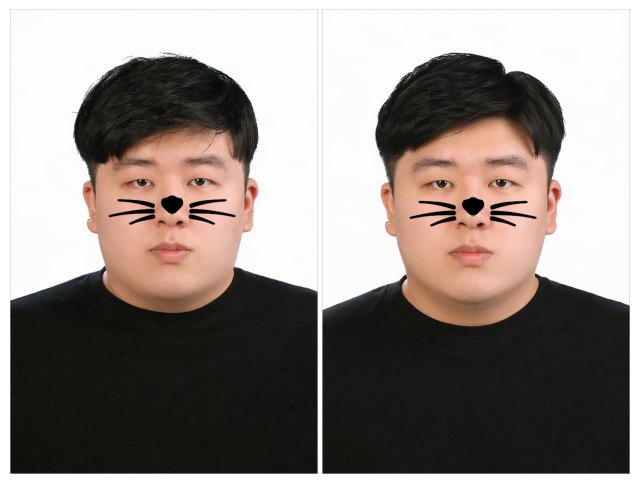

In [20]:
import cv2
import dlib
import matplotlib.pyplot as plt
import numpy as np

# 파일 경로
img_path = "/home/jovyan/work/cv/dksgustn2.png"
predictor_path = "/home/jovyan/work/cv/shape_predictor_68_face_landmarks.dat"
sticker_path = "/home/jovyan/work/cv/cat-whiskers.png"

# 이미지 불러오기
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 스티커 불러오기
sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)

# dlib detector / predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(predictor_path)

# 얼굴 검출
faces = detector(img_rgb, 1)

print("검출된 얼굴 수:", len(faces))

# 결과 이미지
img_result = img_bgr.copy()

for face in faces:
    landmarks = predictor(img_rgb, face)

    # 1. 30번 점을 기준점으로 사용
    center_x = landmarks.part(30).x
    center_y = landmarks.part(30).y

    # 2. 수염 크기 계산
    
    nose_left_x = landmarks.part(31).x
    nose_right_x = landmarks.part(35).x
    nose_width = nose_right_x - nose_left_x

    whisker_width = int(nose_width * 4.8)

    sticker_h, sticker_w = sticker.shape[:2]
    whisker_height = int(sticker_h * whisker_width / sticker_w)

    resized_sticker = cv2.resize(sticker, (whisker_width, whisker_height))

    # 3. 위치 계산
    x = center_x - whisker_width // 2
    y = center_y - whisker_height // 2 - 8

    # 4. 디버깅용 점 표시
    cv2.circle(img_result, (center_x, center_y), 4, (0, 255, 0), -1)

    # 5. 이미지 경계 보정
    h, w = img_result.shape[:2]

    if x < 0:
        x = 0
    if y < 0:
        y = 0

    if x + whisker_width > w:
        whisker_width = w - x
        resized_sticker = resized_sticker[:, :whisker_width]

    if y + whisker_height > h:
        whisker_height = h - y
        resized_sticker = resized_sticker[:whisker_height, :]

    # 6. 스티커 합성
    if resized_sticker.shape[2] == 4:
        sticker_rgb = resized_sticker[:, :, :3]
        alpha = resized_sticker[:, :, 3] / 255.0

        roi = img_result[y:y+whisker_height, x:x+whisker_width]

        for c in range(3):
            roi[:, :, c] = (
                alpha * sticker_rgb[:, :, c]
                + (1 - alpha) * roi[:, :, c]
            )

        img_result[y:y+whisker_height, x:x+whisker_width] = roi

# 결과 출력
img_result_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_result_rgb)
plt.axis("off")
plt.show()

### 4.2 단체사진은 어떨까
- 챗지피티에게 부탁하여 인터넷에서 주워온 어느 등산회에 단체사진과 제 얼굴을 합성해달라고 해서 만든 사진입니다.
- 제가 원본 사진으로 테스트했을때에는 화질이 안좋아서 2명밖에 인식을 하지 못하였는데 제가 만든 사진은 19명으로 인식되는 모습을 보여주고있습니다.
- 하지만 사진의 촬영거리가 멀어서 그런거같은데 다 각기다른 위치에 고양이 코가 붙여져 있습니다. 이부분은 세세한 조정이 필요할거같습니다.

검출된 얼굴 수: 19


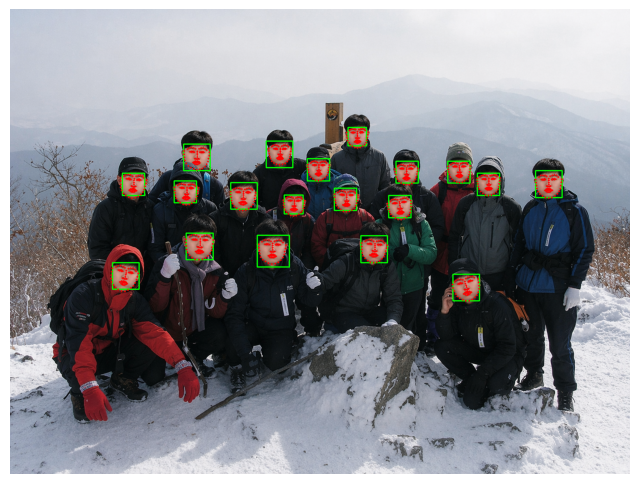

In [23]:
import cv2
import dlib
import matplotlib.pyplot as plt

# 이미지 경로
img_path = "/home/jovyan/work/cv/dksgustn33.png"

# 이미지 읽기
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# dlib 얼굴 검출기
detector = dlib.get_frontal_face_detector()

# 랜드마크 모델 파일 경로
predictor_path = "/home/jovyan/work/cv/shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(predictor_path)

# 얼굴 검출
faces = detector(img_rgb, 1)

print("검출된 얼굴 수:", len(faces))

# 얼굴 박스와 랜드마크 표시용 복사본
img_result = img_rgb.copy()

for face in faces:
    # bounding box 좌표
    x1 = face.left()
    y1 = face.top()
    x2 = face.right()
    y2 = face.bottom()

    # 얼굴 박스 그리기
    cv2.rectangle(img_result, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # 랜드마크 검출 눈코입이 제대로인식되는지 확인
    landmarks = predictor(img_rgb, face)

    # 68개 점 찍기
    for i in range(68):
        x = landmarks.part(i).x
        y = landmarks.part(i).y
        cv2.circle(img_result, (x, y), 2, (255, 0, 0), -1)

# 결과 출력
plt.figure(figsize=(8, 8))
plt.imshow(img_result)
plt.axis('off')
plt.show()

검출된 얼굴 수: 19


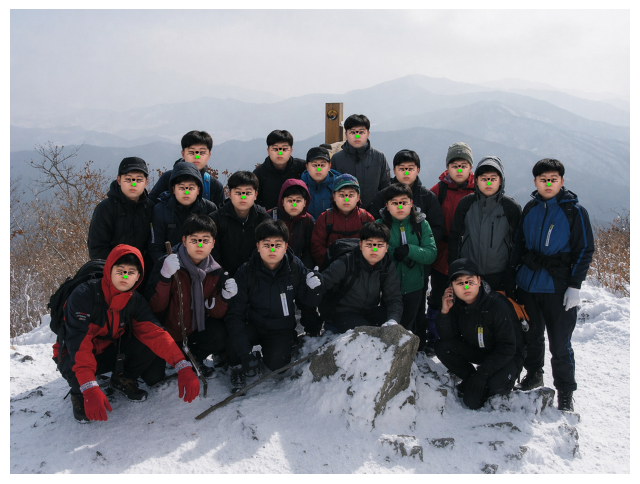

In [25]:
import cv2
import dlib
import matplotlib.pyplot as plt
import numpy as np

# 파일 경로
img_path = "/home/jovyan/work/cv/dksgustn33.png"
predictor_path = "/home/jovyan/work/cv/shape_predictor_68_face_landmarks.dat"
sticker_path = "/home/jovyan/work/cv/cat-whiskers.png"

# 이미지 불러오기
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 스티커 불러오기
sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)

# dlib detector / predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(predictor_path)

# 얼굴 검출
faces = detector(img_rgb, 1)

print("검출된 얼굴 수:", len(faces))

# 결과 이미지
img_result = img_bgr.copy()

for face in faces:
    landmarks = predictor(img_rgb, face)

    # 1. 30번 점을 기준점으로 사용
    center_x = landmarks.part(30).x
    center_y = landmarks.part(30).y

    # 2. 수염 크기 계산
    
    nose_left_x = landmarks.part(31).x
    nose_right_x = landmarks.part(35).x
    nose_width = nose_right_x - nose_left_x

    whisker_width = int(nose_width * 4.8)

    sticker_h, sticker_w = sticker.shape[:2]
    whisker_height = int(sticker_h * whisker_width / sticker_w)

    resized_sticker = cv2.resize(sticker, (whisker_width, whisker_height))

    # 3. 위치 계산
    x = center_x - whisker_width // 2
    y = center_y - whisker_height // 2 - 8

    # 4. 디버깅용 점 표시
    cv2.circle(img_result, (center_x, center_y), 4, (0, 255, 0), -1)

    # 5. 이미지 경계 보정
    h, w = img_result.shape[:2]

    if x < 0:
        x = 0
    if y < 0:
        y = 0

    if x + whisker_width > w:
        whisker_width = w - x
        resized_sticker = resized_sticker[:, :whisker_width]

    if y + whisker_height > h:
        whisker_height = h - y
        resized_sticker = resized_sticker[:whisker_height, :]

    # 6. 스티커 합성
    if resized_sticker.shape[2] == 4:
        sticker_rgb = resized_sticker[:, :, :3]
        alpha = resized_sticker[:, :, 3] / 255.0

        roi = img_result[y:y+whisker_height, x:x+whisker_width]

        for c in range(3):
            roi[:, :, c] = (
                alpha * sticker_rgb[:, :, c]
                + (1 - alpha) * roi[:, :, c]
            )

        img_result[y:y+whisker_height, x:x+whisker_width] = roi

# 결과 출력
img_result_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_result_rgb)
plt.axis("off")
plt.show()

### 4.3 밝기 조절
- 어둡게 해봤을때 눈을 좀 더 잘 인식하는것이 확인됩니다.
- 그리고 입을 잘 인식을 못하는거같습니다.
- 이로써 생각한바로는 어두우면 윤곽을 잘 잡지못하여 점이 잘안찍힐수도있다라는 결론에 도달하였습니다.

검출된 얼굴 수: 1


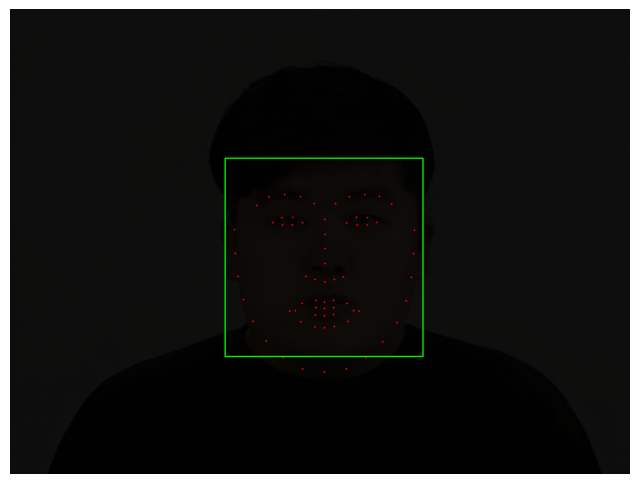

In [26]:
import cv2
import dlib
import matplotlib.pyplot as plt

# 이미지 경로
img_path = "/home/jovyan/work/cv/dksgustn4.png"

# 이미지 읽기
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# dlib 얼굴 검출기
detector = dlib.get_frontal_face_detector()

# 랜드마크 모델 파일 경로
predictor_path = "/home/jovyan/work/cv/shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(predictor_path)

# 얼굴 검출
faces = detector(img_rgb, 1)

print("검출된 얼굴 수:", len(faces))

# 얼굴 박스와 랜드마크 표시용 복사본
img_result = img_rgb.copy()

for face in faces:
    # bounding box 좌표
    x1 = face.left()
    y1 = face.top()
    x2 = face.right()
    y2 = face.bottom()

    # 얼굴 박스 그리기
    cv2.rectangle(img_result, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # 랜드마크 검출 눈코입이 제대로인식되는지 확인
    landmarks = predictor(img_rgb, face)

    # 68개 점 찍기
    for i in range(68):
        x = landmarks.part(i).x
        y = landmarks.part(i).y
        cv2.circle(img_result, (x, y), 2, (255, 0, 0), -1)

# 결과 출력
plt.figure(figsize=(8, 8))
plt.imshow(img_result)
plt.axis('off')
plt.show()

검출된 얼굴 수: 1


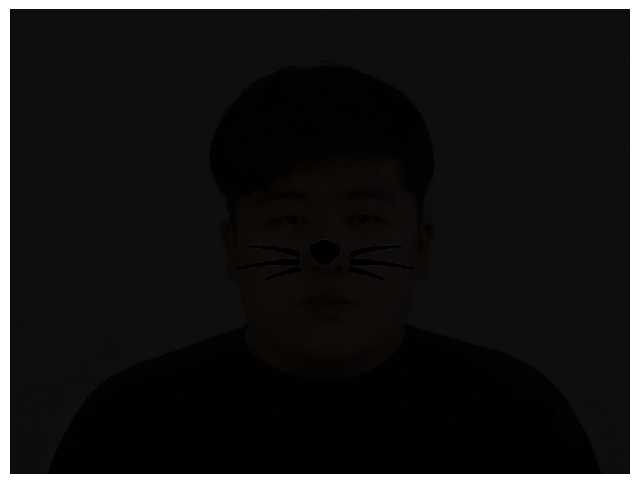

In [27]:
import cv2
import dlib
import matplotlib.pyplot as plt
import numpy as np

# 파일 경로
img_path = "/home/jovyan/work/cv/dksgustn4.png"
predictor_path = "/home/jovyan/work/cv/shape_predictor_68_face_landmarks.dat"
sticker_path = "/home/jovyan/work/cv/cat-whiskers.png"

# 이미지 불러오기
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 스티커 불러오기
sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)

# dlib detector / predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(predictor_path)

# 얼굴 검출
faces = detector(img_rgb, 1)

print("검출된 얼굴 수:", len(faces))

# 결과 이미지
img_result = img_bgr.copy()

for face in faces:
    landmarks = predictor(img_rgb, face)

    # 1. 30번 점을 기준점으로 사용
    center_x = landmarks.part(30).x
    center_y = landmarks.part(30).y

    # 2. 수염 크기 계산
    
    nose_left_x = landmarks.part(31).x
    nose_right_x = landmarks.part(35).x
    nose_width = nose_right_x - nose_left_x

    whisker_width = int(nose_width * 4.8)

    sticker_h, sticker_w = sticker.shape[:2]
    whisker_height = int(sticker_h * whisker_width / sticker_w)

    resized_sticker = cv2.resize(sticker, (whisker_width, whisker_height))

    # 3. 위치 계산
    x = center_x - whisker_width // 2
    y = center_y - whisker_height // 2 - 8

    # 4. 디버깅용 점 표시
    cv2.circle(img_result, (center_x, center_y), 4, (0, 255, 0), -1)

    # 5. 이미지 경계 보정
    h, w = img_result.shape[:2]

    if x < 0:
        x = 0
    if y < 0:
        y = 0

    if x + whisker_width > w:
        whisker_width = w - x
        resized_sticker = resized_sticker[:, :whisker_width]

    if y + whisker_height > h:
        whisker_height = h - y
        resized_sticker = resized_sticker[:whisker_height, :]

    # 6. 스티커 합성
    if resized_sticker.shape[2] == 4:
        sticker_rgb = resized_sticker[:, :, :3]
        alpha = resized_sticker[:, :, 3] / 255.0

        roi = img_result[y:y+whisker_height, x:x+whisker_width]

        for c in range(3):
            roi[:, :, c] = (
                alpha * sticker_rgb[:, :, c]
                + (1 - alpha) * roi[:, :, c]
            )

        img_result[y:y+whisker_height, x:x+whisker_width] = roi

# 결과 출력
img_result_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_result_rgb)
plt.axis("off")
plt.show()